# Zadanie 01 - `Praca z danymi medycznymi: import, przetwarzanie i analiza zbiorów danych pacjentów`

In [37]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

pd.set_option("display.max_columns", 100)

## Etap 1: Import danych

In [38]:
DATA_PATH = "dataset/Smoker_Epigenetic_df.csv"

def load_data(path: str) -> pd.DataFrame:
    _, ext = os.path.splitext(path.lower())
    if ext == ".csv":
        df = pd.read_csv(path)
    elif ext in [".xlsx", ".xls"]:
        df = pd.read_excel(path)
    else:
        raise ValueError("Obsługiwane są tylko pliki .csv oraz .xlsx/.xls")
    return df

df = load_data(DATA_PATH)

# Podstawowe informacje
print("Kształt zbioru:", df.shape)

print("\nPierwsze 5 wierszy:")
print(df.head())

print("\nInformacje o danych:")
df.info()

print("\nTypy danych")
print(df.dtypes)

Kształt zbioru: (683, 24)

Pierwsze 5 wierszy:
          GSM Smoking Status Gender  Age  cg00050873  cg00212031  cg00213748  \
0  GSM1051525        current      f   67    0.607563    0.422843    0.372455   
1  GSM1051526        current      f   49    0.345054    0.568662    0.500600   
2  GSM1051527        current      f   53    0.321350    0.360909    0.352732   
3  GSM1051528        current      f   62    0.277268    0.304437    0.475235   
4  GSM1051529          never      f   33    0.413599    0.131251    0.367545   

   cg00214611  cg00455876  cg01707559  cg02004872  cg02011394  cg02050847  \
0    0.621562    0.290777    0.267143    0.179144    0.480252    0.327608   
1    0.498607    0.374591    0.190274    0.155977    0.418081    0.346463   
2    0.373824    0.230674    0.314705    0.105745    0.615103    0.237539   
3    0.486258    0.295181    0.295793    0.111286    0.301020    0.304535   
4    0.761167    0.235770    0.250526    0.169108    0.392975    0.306226   

   cg0223

## Etap 2: Wstępne przetwarzanie danych

In [39]:
# ------------------------------
# 2. Uzupełnienie brakujących danych i badanie zależności
# ------------------------------

# Sprawdzenie brakujących wartości
print("\nBrakujące wartości w każdej kolumnie:")
print(df.isnull().sum())

# W zbiorze brakuje wartości w kolumnach CpG dla ostatnich 62 wierszy.
# Należy uzupełnić je medianą z kolumn (dla każdej CpG osobno).
# Wybranie kolumn z danymi metylacji (zaczynające się od 'cg')
methyl_cols = [col for col in df.columns if col.startswith('cg')]

# Kopiowanie danych, aby nie modyfikować oryginału
df_imputed = df.copy()

# Imputacja medianą dla kolumn metylacji
imputer = SimpleImputer(strategy='median')
df_imputed[methyl_cols] = imputer.fit_transform(df[methyl_cols])

# Sprawdzenie, czy braki zostały uzupełnione
print("\nBrakujące wartości po imputacji medianą:")
print(df_imputed[methyl_cols].isnull().sum().sum())  # powinno być 0


Brakujące wartości w każdej kolumnie:
GSM                0
Smoking Status     0
Gender             0
Age                0
cg00050873        62
cg00212031        62
cg00213748        62
cg00214611        62
cg00455876        62
cg01707559        62
cg02004872        62
cg02011394        62
cg02050847        62
cg02233190        62
cg02494853        62
cg02839557        62
cg02842889        62
cg03052502        62
cg03155755        62
cg03244189        62
cg03443143        62
cg03683899        62
cg03695421        62
cg03706273        62
dtype: int64

Brakujące wartości po imputacji medianą:
0


## Etap 3: Analiza i wizualizacja

In [40]:
# Statystyki opisowe
print("\nStatystyki opisowe (wybrane kolumny liczbowe):")
print(df.describe())
# display(df.describe())


Statystyki opisowe (wybrane kolumny liczbowe):
              Age  cg00050873  cg00212031  cg00213748  cg00214611  cg00455876  \
count  683.000000  621.000000  621.000000  621.000000  621.000000  621.000000   
mean    53.821376    0.560044    0.309601    0.519059    0.341058    0.447175   
std     11.770048    0.197915    0.192790    0.206209    0.208291    0.197736   
min     18.000000    0.118588    0.006949    0.000000    0.012465    0.059167   
25%     47.000000    0.413118    0.063172    0.363459    0.069461    0.293002   
50%     56.000000    0.505228    0.365545    0.471315    0.415746    0.379676   
75%     62.000000    0.814392    0.459813    0.727751    0.497454    0.662831   
max     80.000000    0.898885    0.709992    0.923640    0.806060    0.854434   

       cg01707559  cg02004872  cg02011394  cg02050847  cg02233190  cg02494853  \
count  621.000000  621.000000  621.000000  621.000000  621.000000  621.000000   
mean     0.214354    0.155418    0.605844    0.543691    0.2

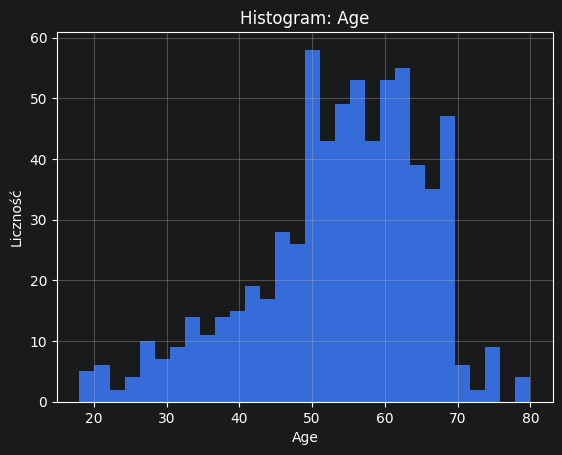

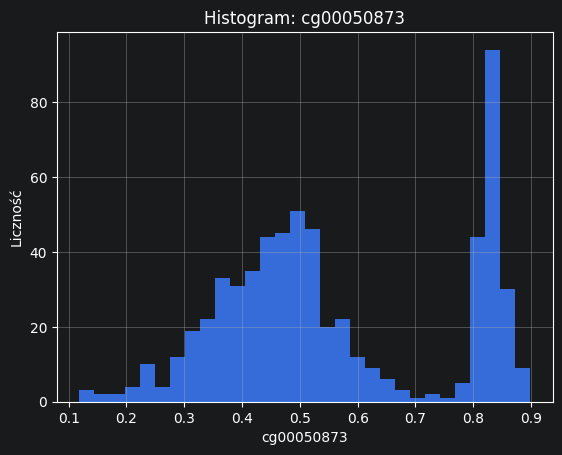

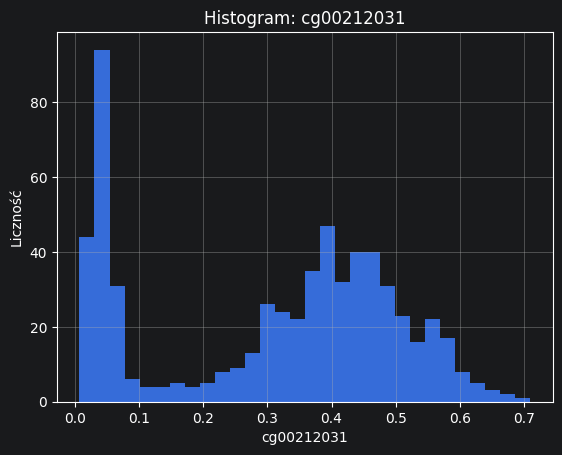

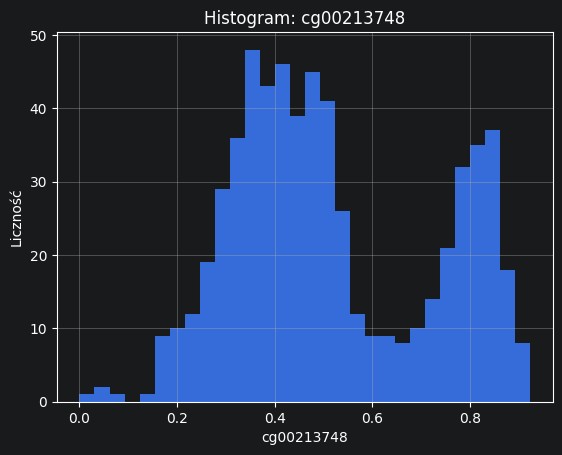

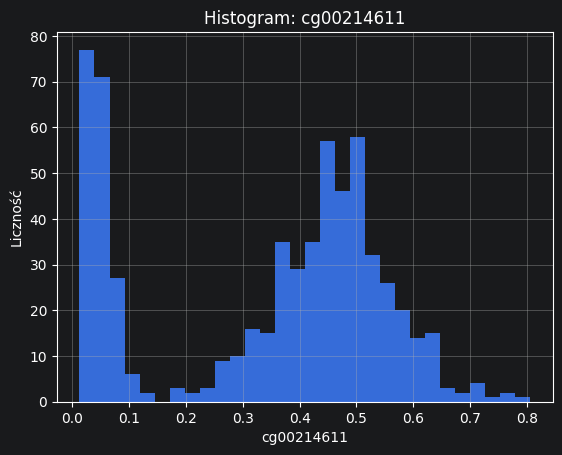

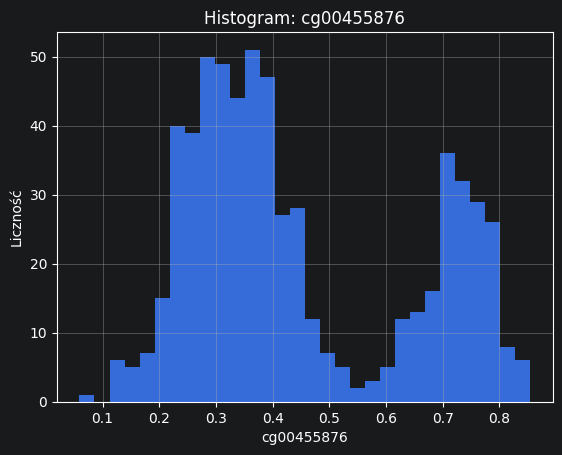

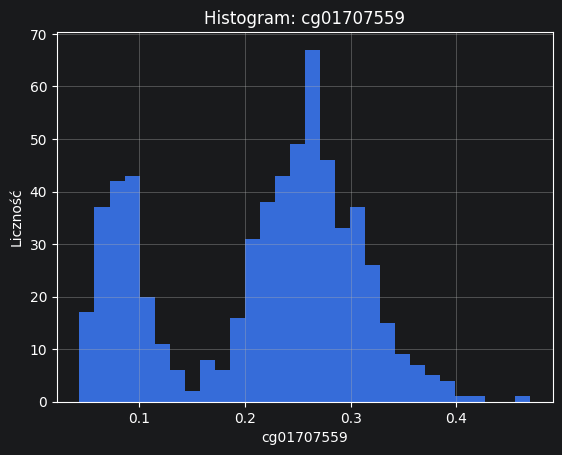

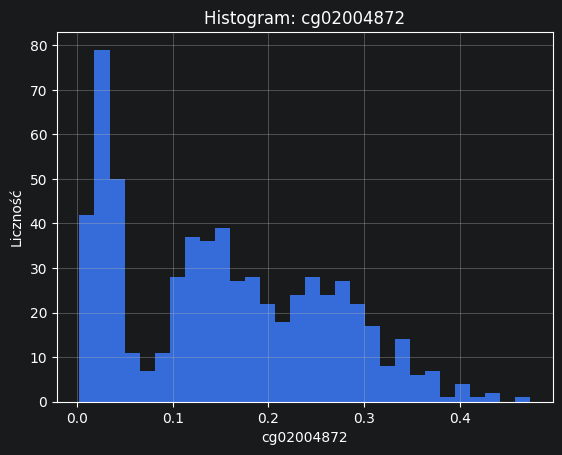

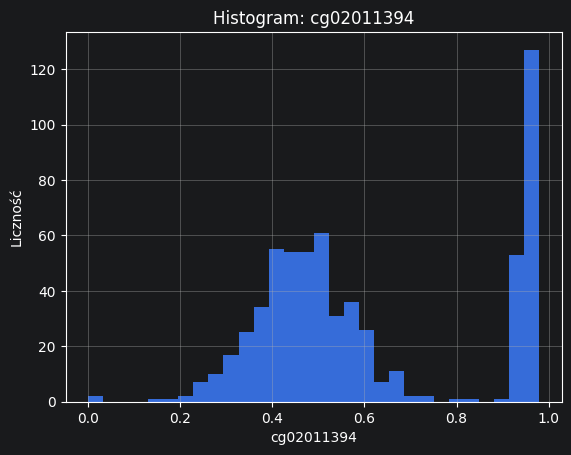

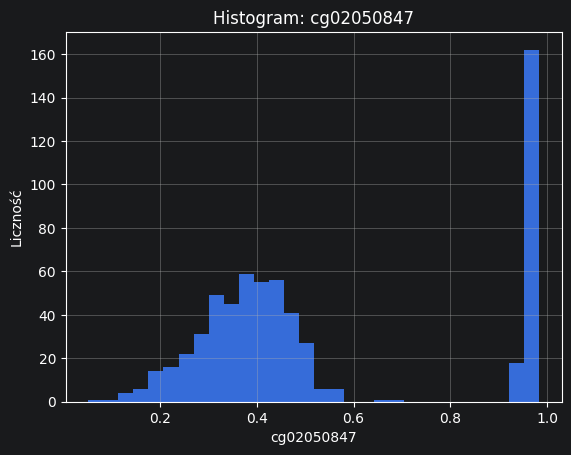

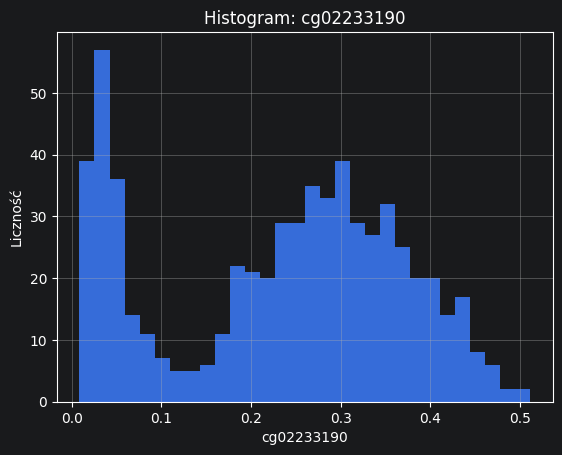

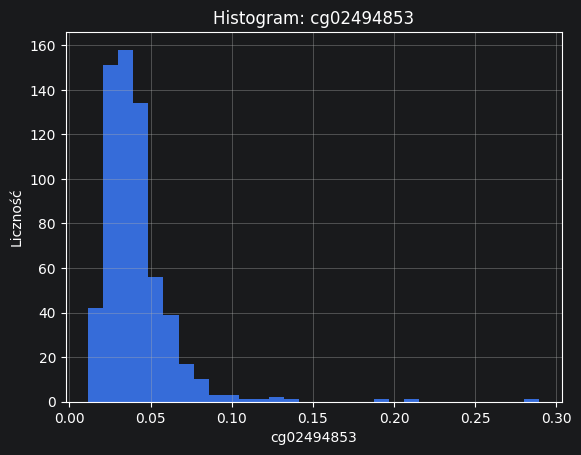

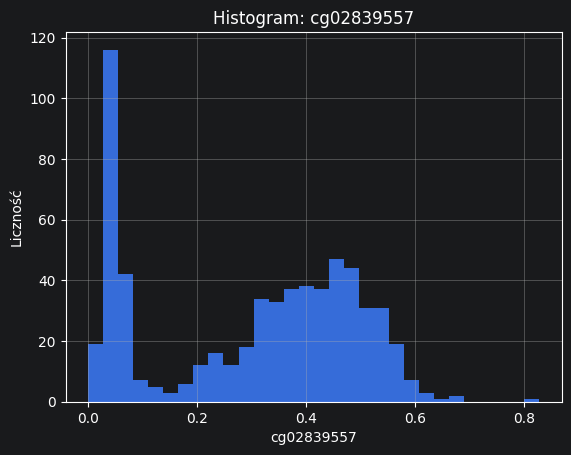

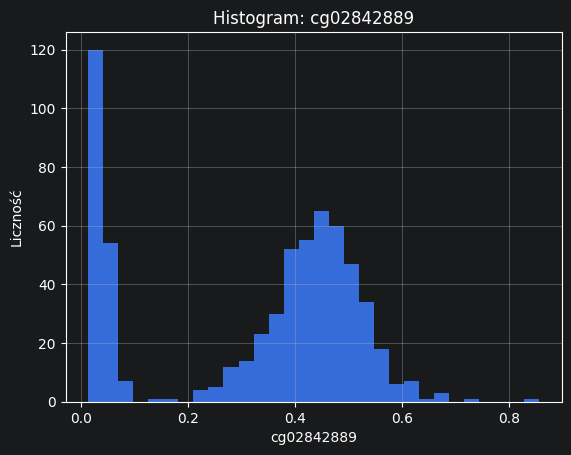

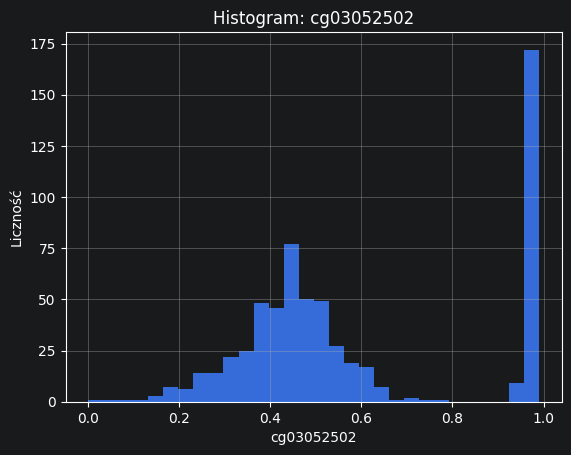

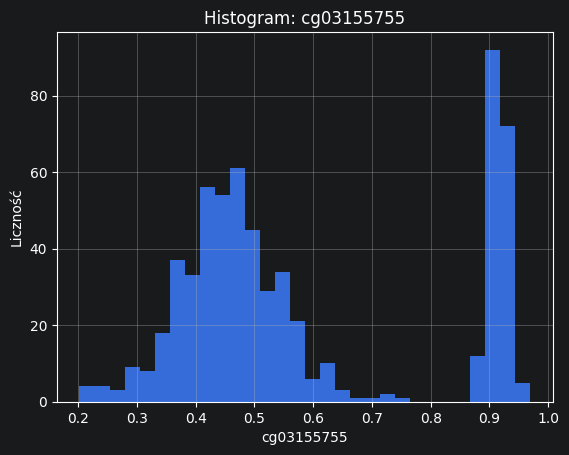

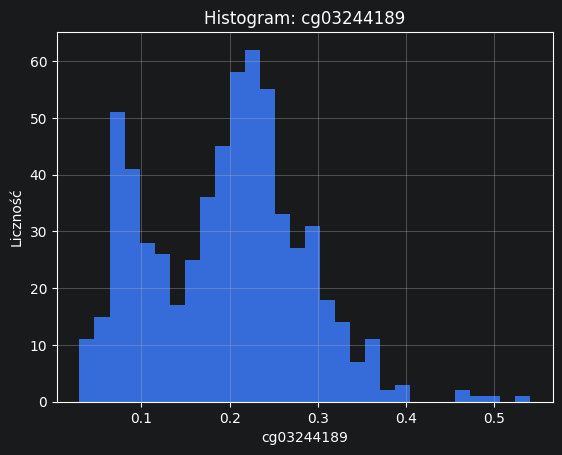

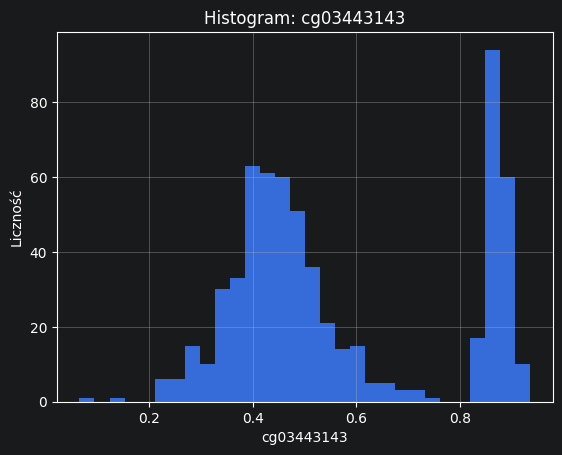

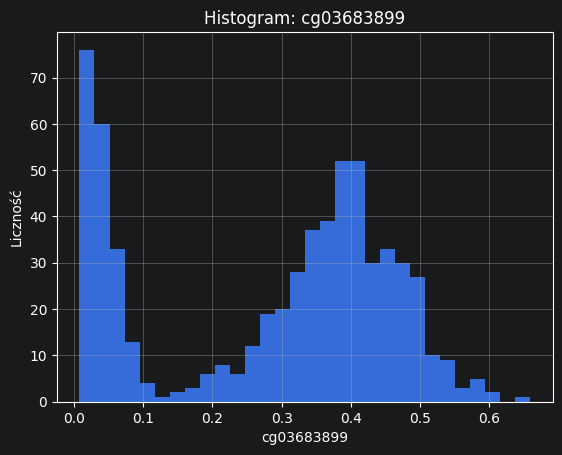

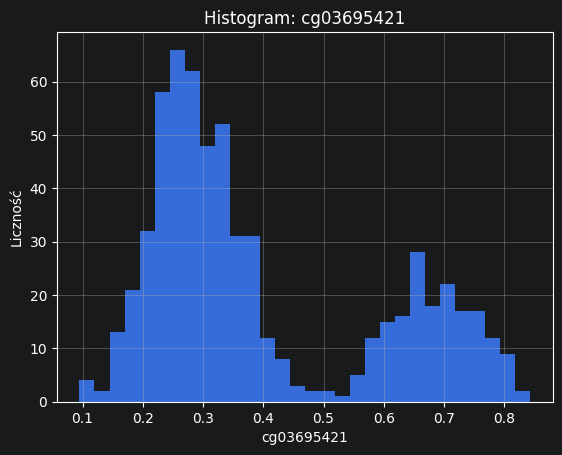

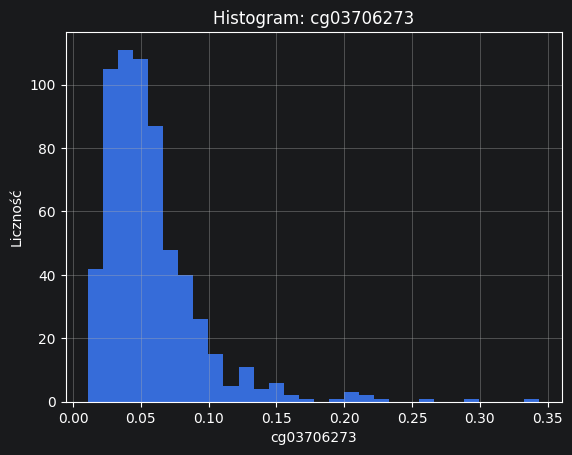

In [41]:

# Histogramy wybranych zmiennych
numeric_candidates = ["Age"] + methyl_cols
numeric_cols = [c for c in numeric_candidates if c in df.columns]

for col in numeric_cols:
    plt.figure()
    df[col].hist(bins=30)
    plt.title(f"Histogram: {col}")
    plt.xlabel(col)
    plt.ylabel("Liczność")
    plt.show()

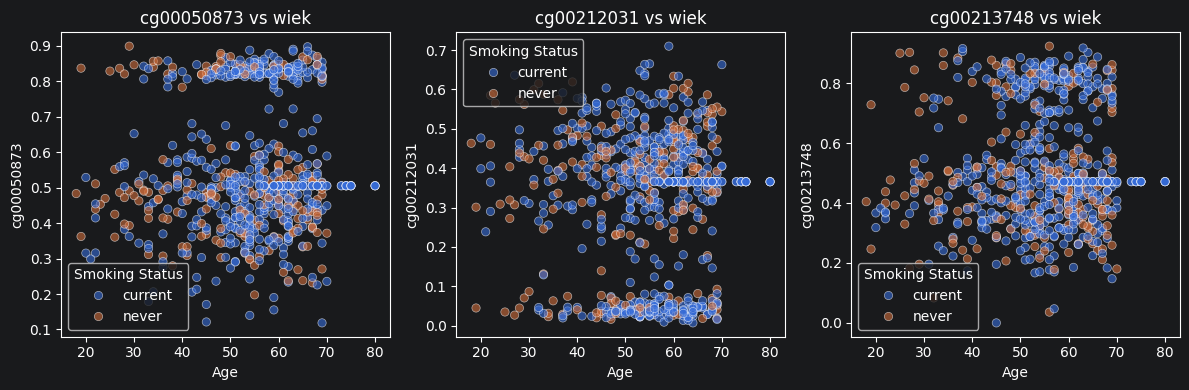

In [42]:

# Wybór kolumn metylacji (CpG) do analizy zależności
sample_cpg = methyl_cols

# Wizualizacja zależności między wiekiem a wybranymi wartościami CpG, z podziałem na palaczy/niepalących
plt.figure(figsize=(12, 4))
for i, cpg in enumerate(sample_cpg[:3]):
    if cpg in df_imputed.columns:
        plt.subplot(1, 3, i+1)
        sns.scatterplot(data=df_imputed, x='Age', y=cpg, hue='Smoking Status', alpha=0.6)
        plt.title(f'{cpg} vs wiek')
plt.tight_layout()
plt.show()


In [43]:
# Wybór zestawów kolumn do wizualizacji (boxplot, macierz korelacji)
corr_cols = []
col = []

for i in range(len(methyl_cols)):
    if i % 5 == 0:
        col = ["Age"]
    # print(i % 5)
    col.append(methyl_cols[i])
    if i % 5 == 4:
        corr_cols.append(col)


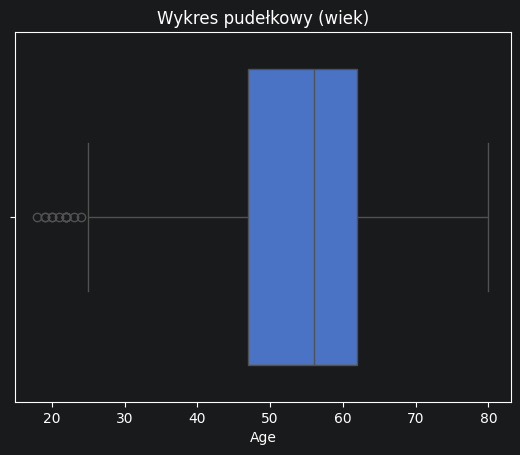

In [44]:
# Boxplot (wiek)
plt.figure()
sns.boxplot(data=df["Age"], orient="h")
plt.title("Wykres pudełkowy (wiek)")
plt.show()

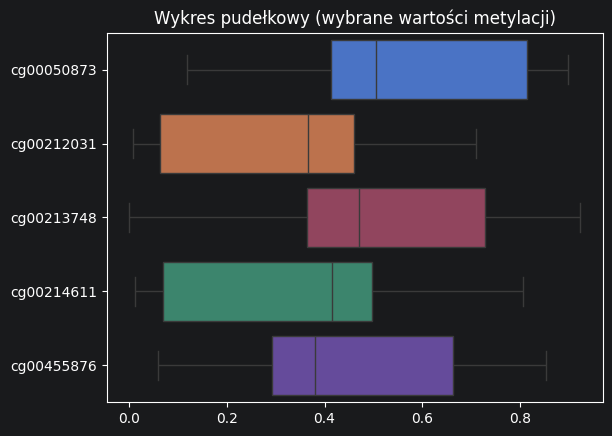

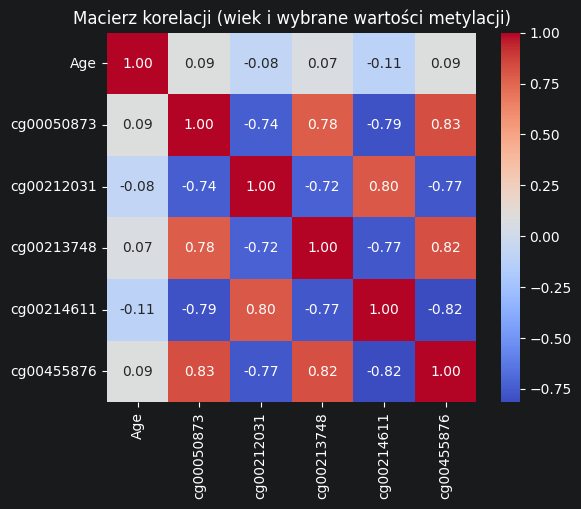

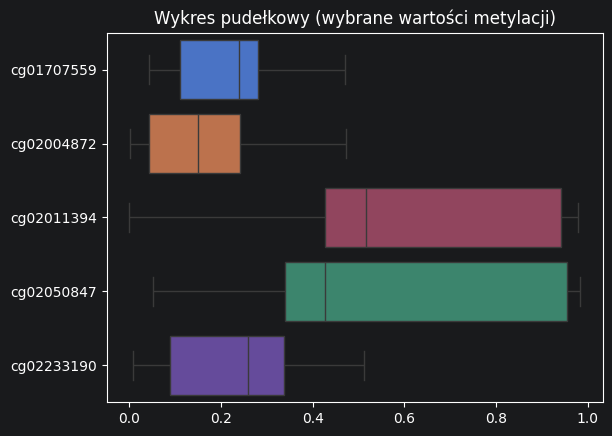

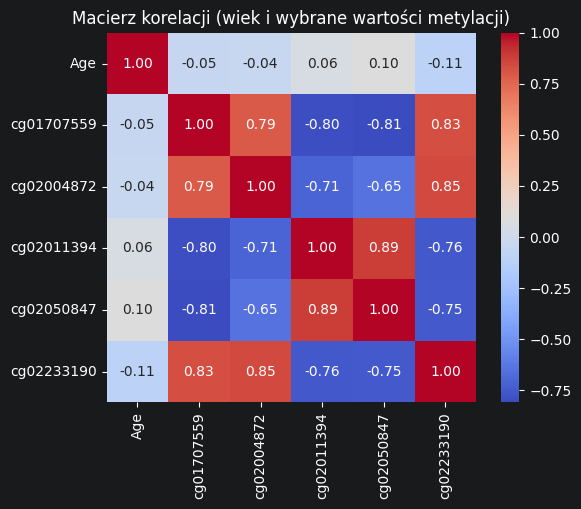

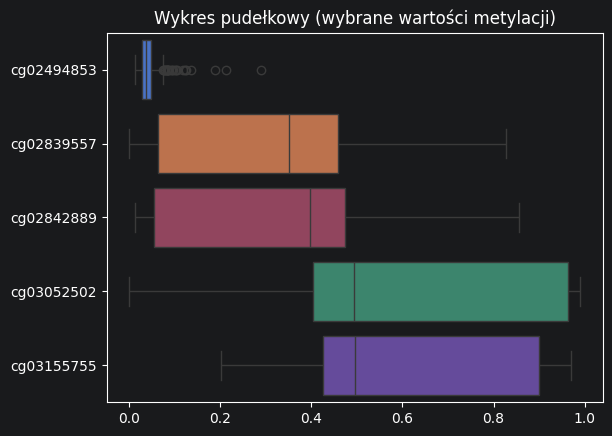

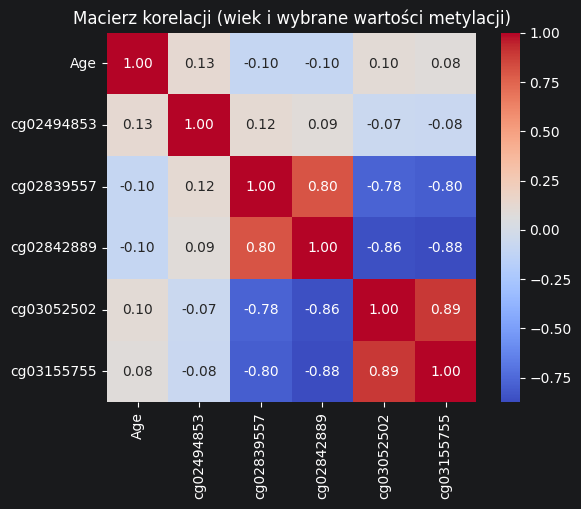

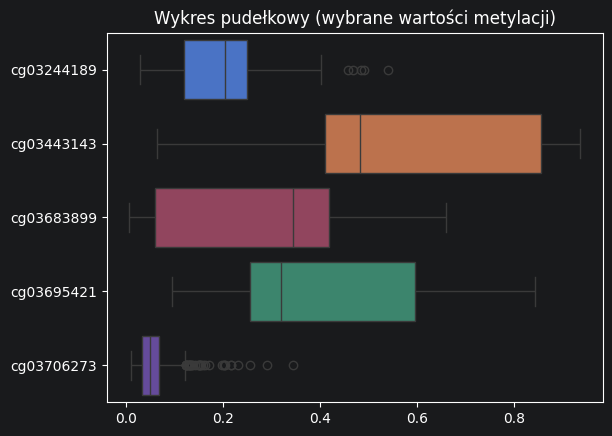

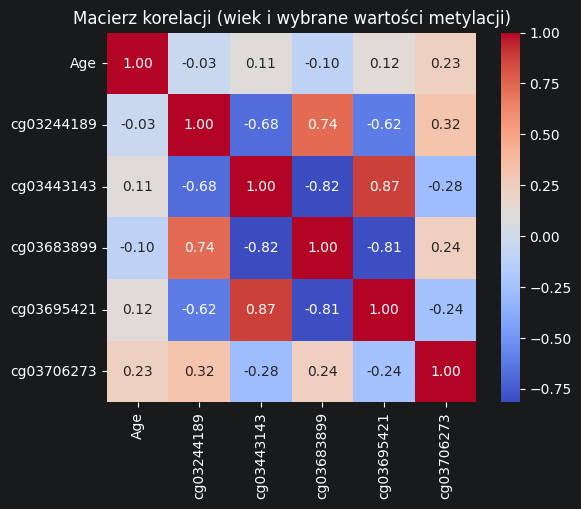

In [45]:
# Boxplot i macierz korelacji dla każdego zestawu kolumn
for cols in corr_cols:

    # Boxplot
    if cols:
        boxplot_cols = cols.copy()
        boxplot_cols.remove("Age")

        plt.figure()
        sns.boxplot(data=df[boxplot_cols], orient="h")
        plt.title("Wykres pudełkowy (wybrane wartości metylacji)")
        plt.show()

    # Macierz korelacji
    if len(cols) >= 2:
        corr = df[cols].corr(numeric_only=True)
        plt.figure()
        sns.heatmap(corr, annot=True, fmt=".2f", square=True, cmap="coolwarm")
        plt.title("Macierz korelacji (wiek i wybrane wartości metylacji)")
        plt.show()


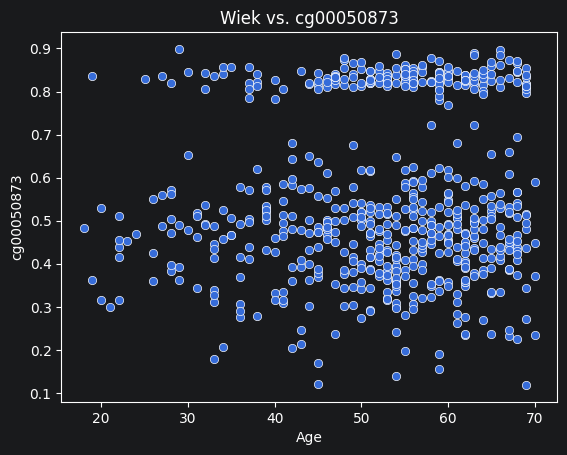

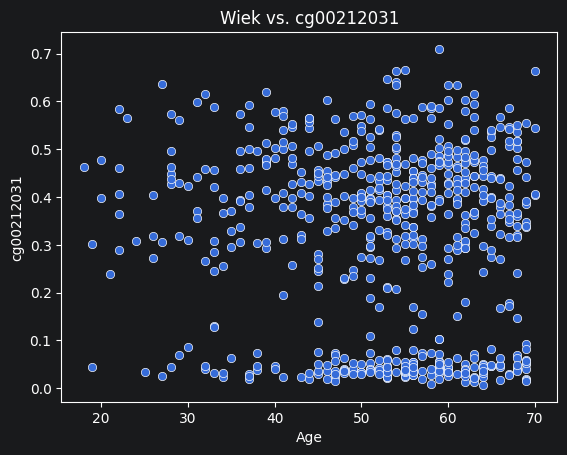

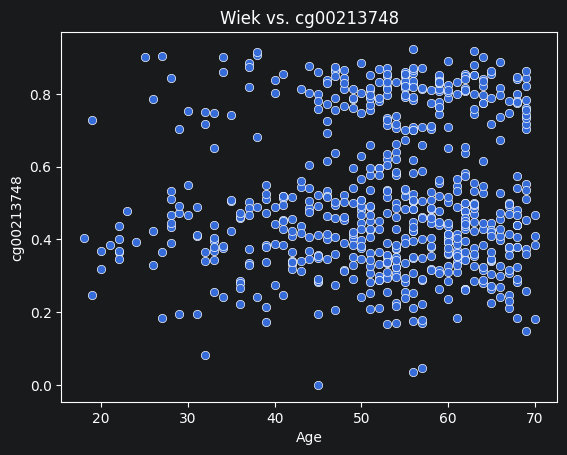

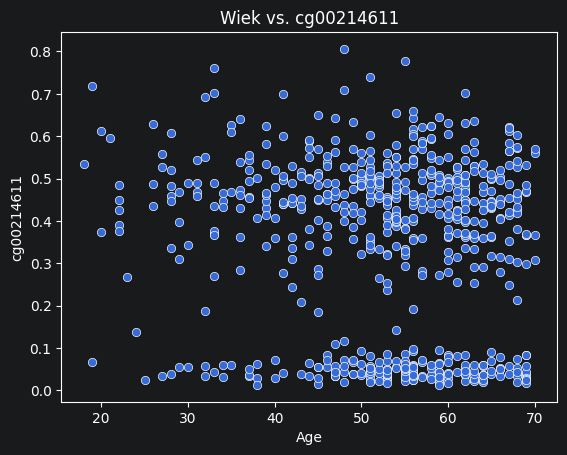

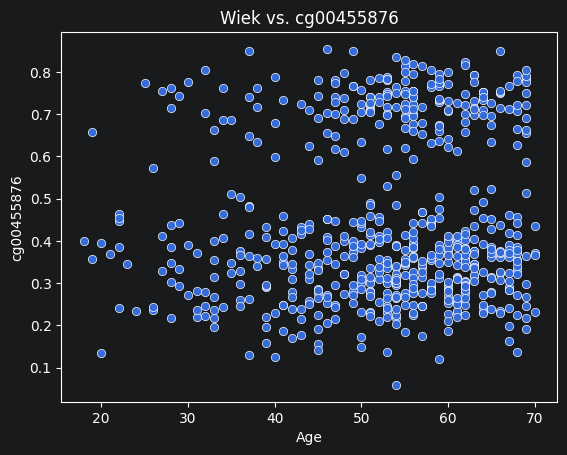

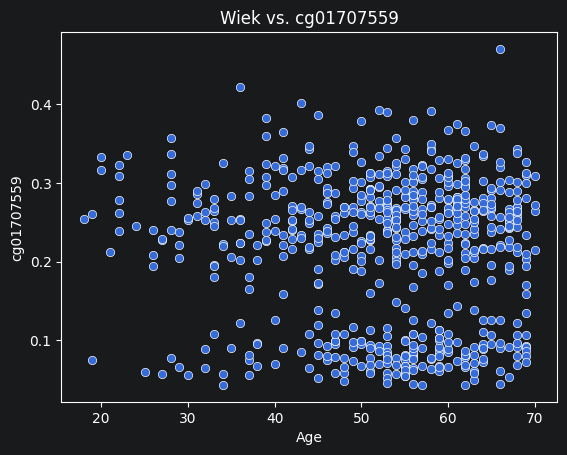

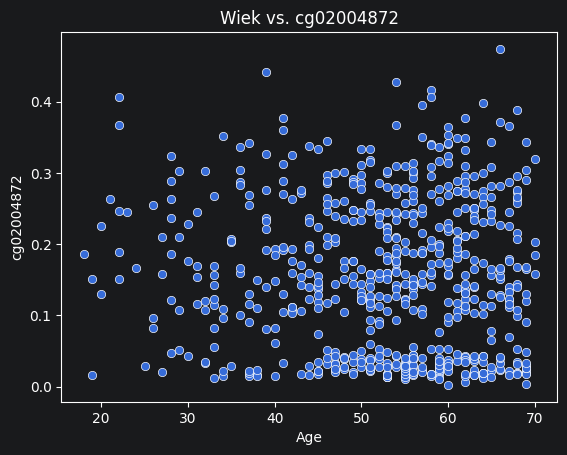

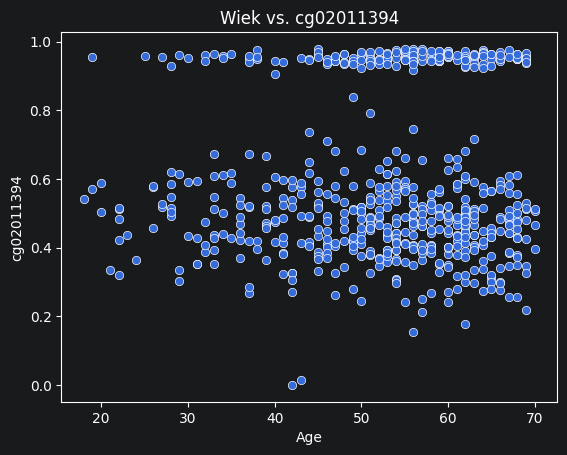

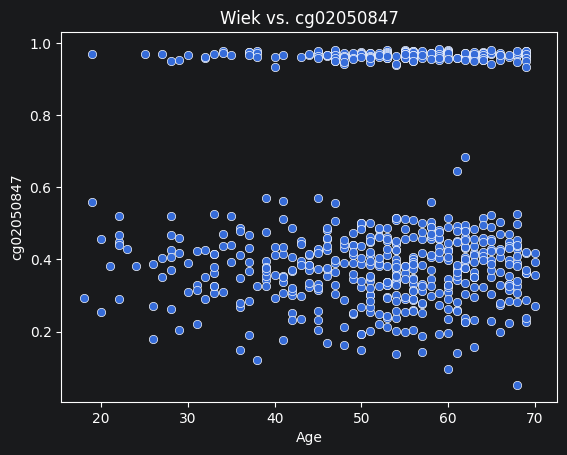

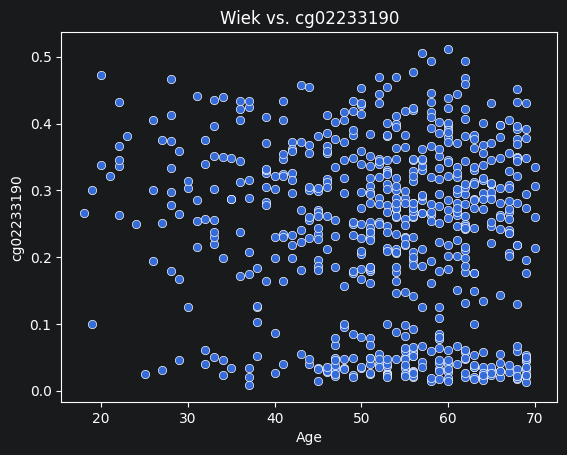

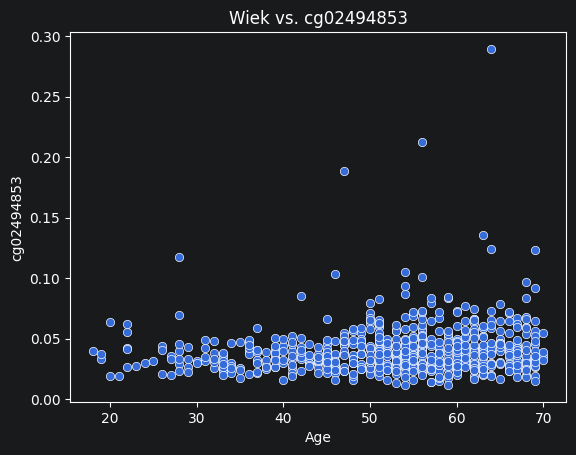

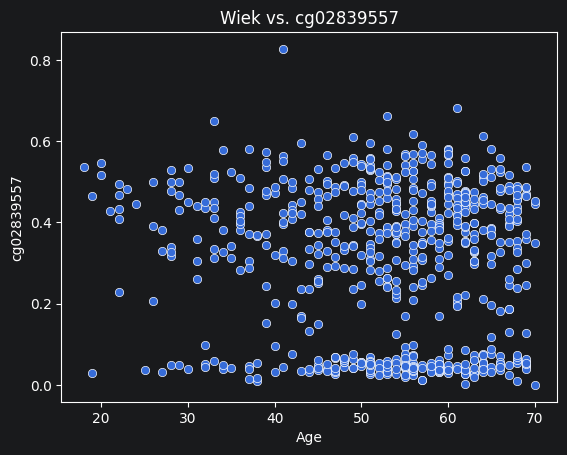

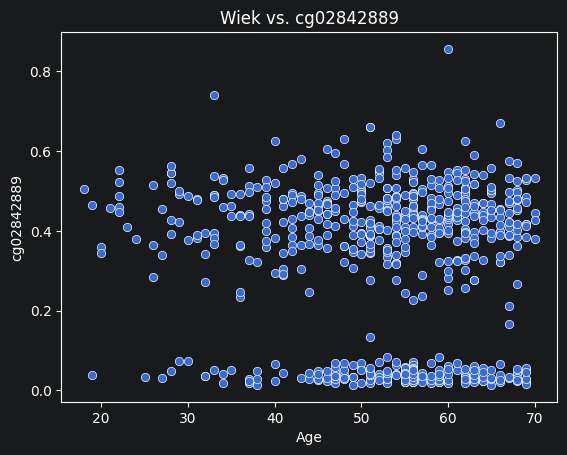

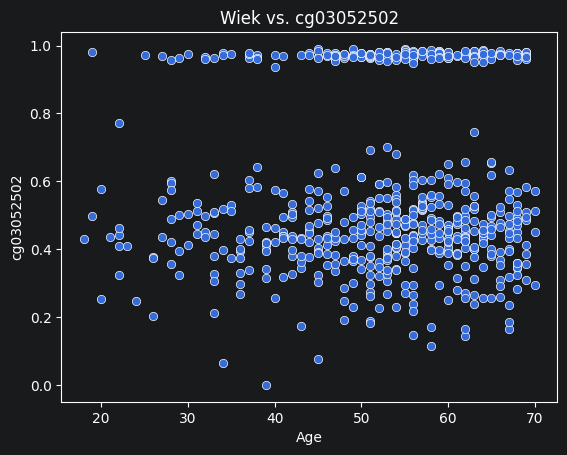

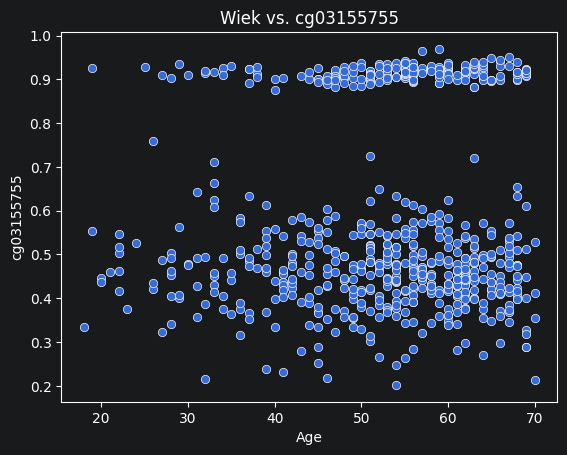

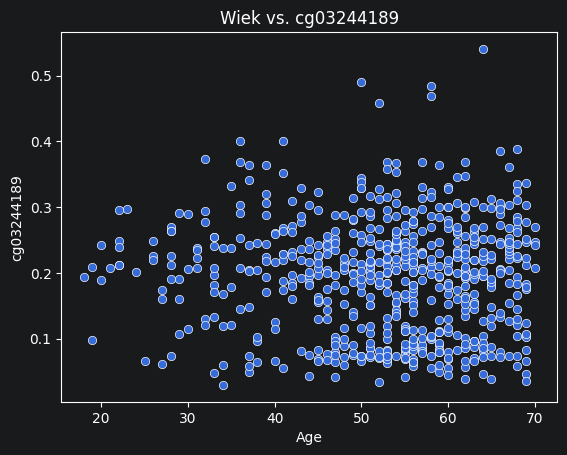

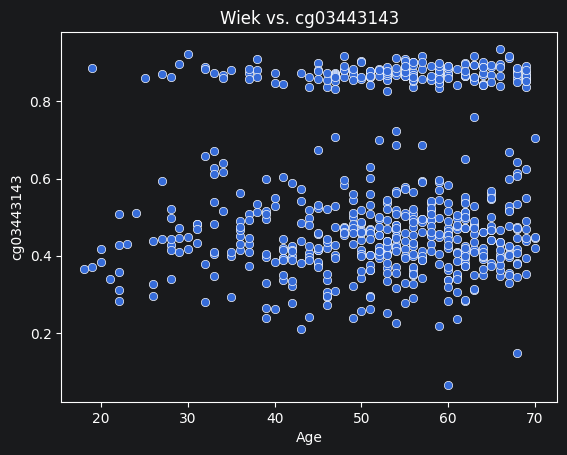

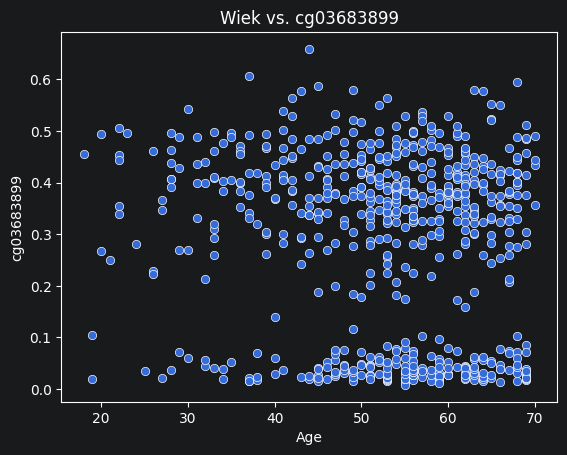

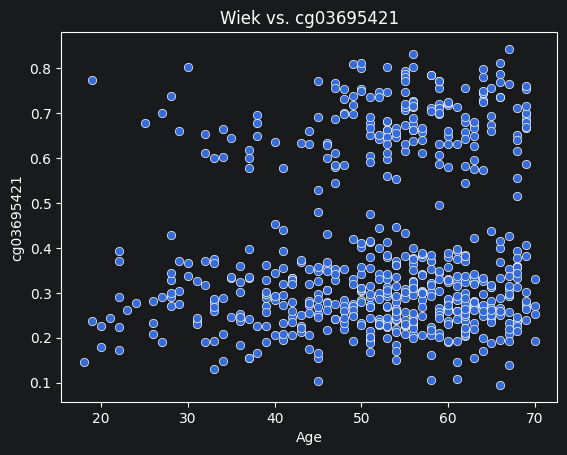

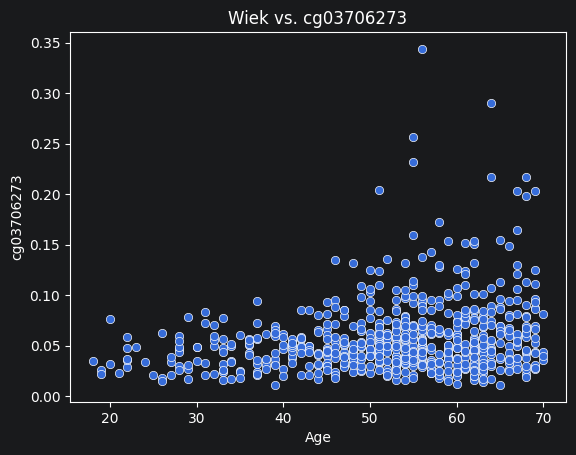

In [46]:

# Zależność: wiek vs. wartości metylacji
for col in methyl_cols:
    if {"Age", col}.issubset(df.columns):
        plt.figure()
        sns.scatterplot(data=df, x="Age", y=col)
        plt.title(f"Wiek vs. {col}")
        plt.show()


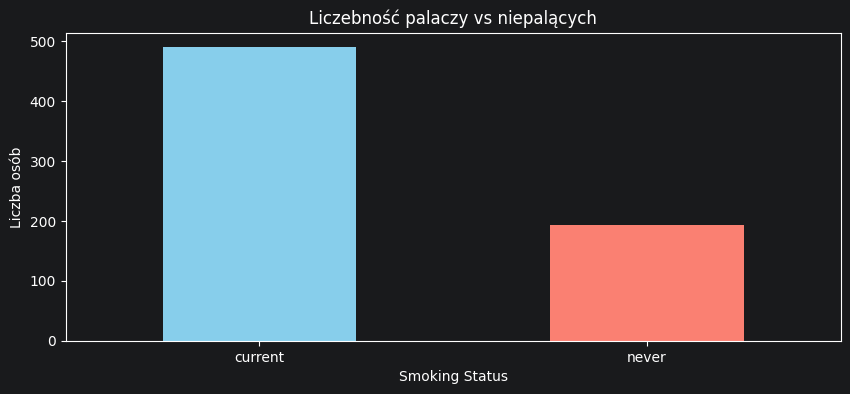

In [47]:
# ------------------------------
# 3. Wizualizacja częstości występowania kategorii w populacji
# ------------------------------

# Rozkład statusu palenia
plt.figure(figsize=(10, 4))
df['Smoking Status'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Liczebność palaczy vs niepalących')
plt.ylabel('Liczba osób')
plt.xticks(rotation=0)
plt.show()

In [48]:
# Normalizacja wartości w kolumnie "Gender"
display(df["Gender"].value_counts())

df["Gender"] = df["Gender"].str.lower()

display(df["Gender"].value_counts())


Gender
f    440
m    181
M     49
F     13
Name: count, dtype: int64

Gender
f    453
m    230
Name: count, dtype: int64

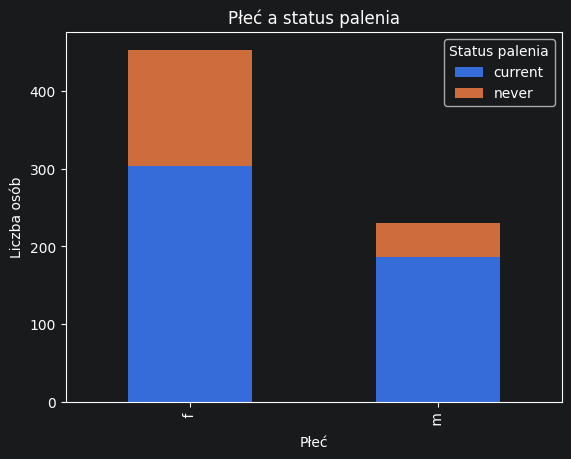

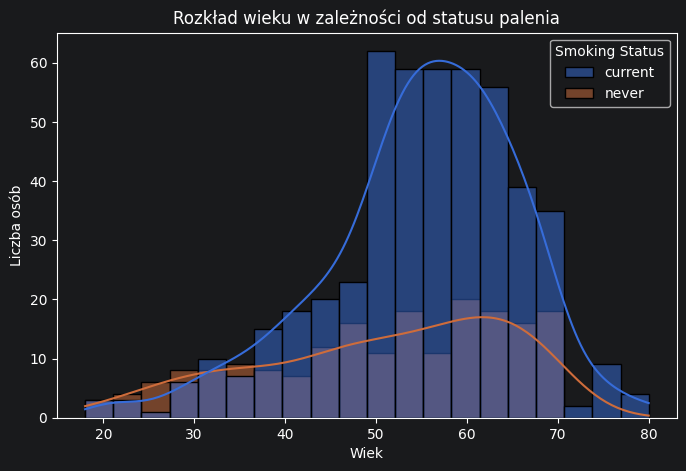

In [51]:

# Rozkład płci w zależności od palenia
pd.crosstab(df['Gender'], df['Smoking Status']).plot(kind='bar', stacked=True)
plt.title('Płeć a status palenia')
plt.xlabel('Płeć')
plt.ylabel('Liczba osób')
plt.legend(title='Status palenia')
plt.show()

# Rozkład wieku w grupach
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='Age', hue='Smoking Status', kde=True, bins=20)
plt.title('Rozkład wieku w zależności od statusu palenia')
plt.xlabel('Wiek')
plt.ylabel('Liczba osób')
plt.show()

## Etap 4: Przygotowanie do modelowania


--- Wyniki modelu bez normalizacji ---
Dokładność (accuracy): 0.715
AUC ROC: 0.586
Raport klasyfikacji:
              precision    recall  f1-score   support

   Niepalący       0.00      0.00      0.00        39
      Palący       0.72      1.00      0.83        98

    accuracy                           0.72       137
   macro avg       0.36      0.50      0.42       137
weighted avg       0.51      0.72      0.60       137



E:\Users\dawid\anaconda3\envs\ok_env\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
E:\Users\dawid\anaconda3\envs\ok_env\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
E:\Users\dawid\anaconda3\envs\ok_env\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.sh

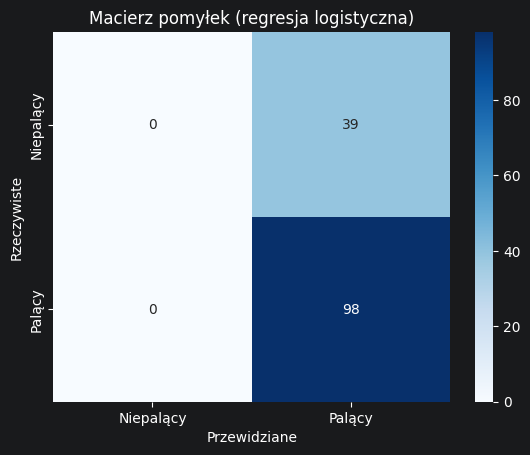

In [52]:
# ------------------------------
# 4. Budowa prostego modelu predykcyjnego (regresja logistyczna)
# ------------------------------

# Przygotowanie cech i celu
X = df_imputed[methyl_cols].copy()  # wszystkie CpG jako cechy
y = (df_imputed['Smoking Status'] == 'current').astype(int)  # 1 = palący, 0 = niepalący

# Podział na zbiór treningowy i testowy (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Model regresji logistycznej (bez normalizacji)
model_raw = LogisticRegression(max_iter=1000, random_state=42)
model_raw.fit(X_train, y_train)
y_pred_raw = model_raw.predict(X_test)
y_proba_raw = model_raw.predict_proba(X_test)[:, 1]

print("\n--- Wyniki modelu bez normalizacji ---")
print(f"Dokładność (accuracy): {accuracy_score(y_test, y_pred_raw):.3f}")
print(f"AUC ROC: {roc_auc_score(y_test, y_proba_raw):.3f}")
print("Raport klasyfikacji:")
print(classification_report(y_test, y_pred_raw, target_names=['Niepalący', 'Palący']))

# Macierz pomyłek
cm = confusion_matrix(y_test, y_pred_raw)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Niepalący', 'Palący'], yticklabels=['Niepalący', 'Palący'])
plt.title('Macierz pomyłek (regresja logistyczna)')
plt.xlabel('Przewidziane')
plt.ylabel('Rzeczywiste')
plt.show()

## Etap 5: Porównanie skuteczności metod normalizacji

In [53]:
# ------------------------------
# 5. Porównanie dwóch metod normalizacji danych
# ------------------------------

# StandardScaler vs MinMaxScaler w potoku z imputacją
# Użycie walidacji krzyżowej 5-krotnej, aby ocenić stabilność.

# Definicja potoków
def make_pipeline(scaler):
    return Pipeline([
        ('scaler', scaler),
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
    ])

pipeline_standard = make_pipeline(StandardScaler())
pipeline_minmax = make_pipeline(MinMaxScaler())

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores_standard = cross_val_score(pipeline_standard, X, y, cv=cv, scoring='accuracy')
scores_minmax = cross_val_score(pipeline_minmax, X, y, cv=cv, scoring='accuracy')

print("\n--- Porównanie normalizacji (5-krotna walidacja krzyżowa) ---")
print(f"StandardScaler: średnia dokładność = {scores_standard.mean():.4f} (+/- {scores_standard.std():.4f})")
print(f"MinMaxScaler:   średnia dokładność = {scores_minmax.mean():.4f} (+/- {scores_minmax.std():.4f})")

# Test statystyczny (t-test dla prób zależnych)
from scipy.stats import ttest_rel
t_stat, p_val = ttest_rel(scores_standard, scores_minmax)
print(f"\nTest t-Studenta dla par: t = {t_stat:.4f}, p = {p_val:.4f}")
if p_val < 0.05:
    print("Różnica między metodami normalizacji jest statystycznie istotna.")
else:
    print("Brak statystycznie istotnej różnicy między metodami normalizacji.")

# Porównanie AUC
scores_standard_auc = cross_val_score(pipeline_standard, X, y, cv=cv, scoring='roc_auc')
scores_minmax_auc = cross_val_score(pipeline_minmax, X, y, cv=cv, scoring='roc_auc')
print(f"\nAUC ROC: StandardScaler = {scores_standard_auc.mean():.4f}, MinMaxScaler = {scores_minmax_auc.mean():.4f}")


--- Porównanie normalizacji (5-krotna walidacja krzyżowa) ---
StandardScaler: średnia dokładność = 0.7101 (+/- 0.0182)
MinMaxScaler:   średnia dokładność = 0.7174 (+/- 0.0026)

Test t-Studenta dla par: t = -0.8743, p = 0.4313
Brak statystycznie istotnej różnicy między metodami normalizacji.

AUC ROC: StandardScaler = 0.5502, MinMaxScaler = 0.5540
